## Iteration 2: Optimizing parameters in TF-IDF Vectorization


### Initial Set-up

In [81]:
import pandas as pd
import numpy as np
import gensim
import nltk
import string
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import gensim
import nltk
import string
import textstat
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from collections import Counter
from gensim.models import KeyedVectors
from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler
import ast
from scipy.sparse import hstack
from sklearn.model_selection import learning_curve


print("Libraries imported successfully.")

Libraries imported successfully.


## Modelling

In [82]:
# Step 1: Load Dataset
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\data\preprocessed\groups.csv"
df = pd.read_csv(data_path)

# Keep only the necessary columns
columns_to_keep = ['processed_text', 'emotion', 'emotion_code', 'sub_emotion']
df = df[columns_to_keep]

# Display dataset preview
print("Step 1: Dataset loaded successfully. Preview:")
display(df.head())

Step 1: Dataset loaded successfully. Preview:


,processed_text,emotion,emotion_code,sub_emotion
0,Did you kiss ?,surprise,4,curiosity
1,Yeah .,neutral,6,neutral
2,But no !,anger,2,annoyance
3,Why do you have a problem ?,surprise,4,confusion
4,Did you kiss ?,surprise,4,curiosity


In [83]:
# Step 2: Check for missing processed_text values
missing_values = df['processed_text'].isna().sum()
print(f"Step 2: Number of missing rows in 'processed_text' column: {missing_values}")

# Drop missing values if any
df_cleaned = df.dropna(subset=['processed_text'])
print(f"Step 2: Number of rows after removing missing text: {df_cleaned.shape[0]}")

Step 2: Number of missing rows in 'processed_text' column: 0
Step 2: Number of rows after removing missing text: 24295


In [84]:
# Step 3: Split Data into Training, Validation, and Testing Sets
X_train, X_temp, y_train, y_temp = train_test_split(
    df_cleaned['processed_text'].astype(str),  # Convert to string
    df_cleaned['emotion_code'],  # Labels
    test_size=0.3, random_state=42, stratify=df_cleaned['emotion_code']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display split dataset details
print(f"Step 3: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Step 3: Data successfully split into training, validation, and testing sets.
Training set size: 17006 samples
Validation set size: 3644 samples
Testing set size: 3645 samples


In [85]:
# Step 4: Hyperparameter tuning for TF-IDF

# Define TF-IDF configurations
ngram_ranges = [(1, 1), (1, 2), (1, 3)]
max_features_list = [2500, 5000, 7500, 10000, 15000]
stop_words_options = [None, 'english']
sublinear_tf_options = [False, True]

# Generate all TF-IDF parameter combinations
tfidf_configs = [
    {
        'ngram_range': n,
        'max_features': m,
        'stop_words': s,
        'sublinear_tf': sub
    }
    for n in ngram_ranges
    for m in max_features_list
    for s in stop_words_options
    for sub in sublinear_tf_options
]

# Display TF-IDF configurations
results = []
print(f"\nStep 4: Testing {len(tfidf_configs)} TF-IDF configurations...")

for i, config in enumerate(tfidf_configs):
    print(f"\n=== Config {i + 1}/{len(tfidf_configs)} ===")
    print(f"Params: ngram_range={config['ngram_range']}, max_features={config['max_features']}, stop_words={config['stop_words']}, sublinear_tf={config['sublinear_tf']}")

    # TF-IDF setup
    tfidf_params = {
        'ngram_range': config['ngram_range'],
        'max_features': config['max_features'],
        'stop_words': config['stop_words'],
        'sublinear_tf': config['sublinear_tf']
    }

    # Fit vectorizer
    vectorizer = TfidfVectorizer(**tfidf_params)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)

    # Train logistic regression with default settings (no class_weight tuning yet)
    logreg_model = LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        random_state=42
    )
    logreg_model.fit(X_train_tfidf, y_train)

    # Evaluate
    y_val_pred = logreg_model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Validation Accuracy: {acc:.4f}, F1-score (weighted): {f1:.4f}")

    # Store result
    results.append({
        'config': config,
        'accuracy': acc,
        'f1': f1,
        'model': logreg_model,
        'vectorizer': vectorizer
    })

# Select best result by F1-score
best_result = max(results, key=lambda x: x['f1'])
best_config = best_result['config']
logreg_model = best_result['model']
vectorizer = best_result['vectorizer']

print(f"\nStep 4: Hyperparameter tuning for TF-IDF completed. Best configuration:")
print(f"ngram_range={best_config['ngram_range']}, max_features={best_config['max_features']}, stop_words={best_config['stop_words']}, sublinear_tf={best_config['sublinear_tf']}")
print(f"Best Validation F1-score: {best_result['f1']:.4f}, Accuracy: {best_result['accuracy']:.4f}")



Step 4: Testing 60 TF-IDF configurations...

=== Config 1/60 ===
Params: ngram_range=(1, 1), max_features=2500, stop_words=None, sublinear_tf=False
Validation Accuracy: 0.5960, F1-score (weighted): 0.5453

=== Config 2/60 ===
Params: ngram_range=(1, 1), max_features=2500, stop_words=None, sublinear_tf=True
Validation Accuracy: 0.5952, F1-score (weighted): 0.5450

=== Config 3/60 ===
Params: ngram_range=(1, 1), max_features=2500, stop_words=english, sublinear_tf=False
Validation Accuracy: 0.5475, F1-score (weighted): 0.4848

=== Config 4/60 ===
Params: ngram_range=(1, 1), max_features=2500, stop_words=english, sublinear_tf=True
Validation Accuracy: 0.5477, F1-score (weighted): 0.4847

=== Config 5/60 ===
Params: ngram_range=(1, 1), max_features=5000, stop_words=None, sublinear_tf=False
Validation Accuracy: 0.5971, F1-score (weighted): 0.5461

=== Config 6/60 ===
Params: ngram_range=(1, 1), max_features=5000, stop_words=None, sublinear_tf=True
Validation Accuracy: 0.5974, F1-score (weig

In [86]:
# Step 5: Apply best TF-IDF vectorizer from tuning (already fitted)
X_train_tfidf = vectorizer.transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Step 5: TF-IDF transformation completed with best configuration.")
print(f"Feature shape: {X_train_tfidf.shape}")


Step 5: TF-IDF transformation completed with best configuration.
Feature shape: (17006, 10000)


In [87]:
# Step 6: Reuse best Logistic Regression model from tuning
# (model was already trained during hyperparameter tuning)

print("Step 6: Logistic Regression model already trained with best configuration.")

Step 6: Logistic Regression model already trained with best configuration.


In [88]:
# Step 7: Make Predictions
y_val_pred = logreg_model.predict(X_val_tfidf)
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 7: Model prediction completed for validation and test sets.")

Step 7: Model prediction completed for validation and test sets.


In [89]:
# Create a mapping from emotion_code to emotion label
target_names = df_cleaned.sort_values("emotion_code")['emotion'].unique()

# Step 8: Model Evaluation
print("Step 8: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred, target_names=target_names, zero_division=1))

print("Step 8: Test Set Evaluation Completed.")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("Test Classification Report:\n", classification_report(y_test, y_test_pred, target_names=target_names, zero_division=1))


Step 8: Validation Set Evaluation Completed.
Validation Accuracy: 0.62
Validation Classification Report:
               precision    recall  f1-score   support

   happiness       0.63      0.24      0.35       489
     sadness       0.67      0.07      0.12       148
       anger       0.76      0.14      0.24       221
        fear       0.83      0.04      0.08       117
    surprise       0.70      0.55      0.61       880
     disgust       1.00      0.00      0.00        23
     neutral       0.60      0.91      0.72      1766

    accuracy                           0.62      3644
   macro avg       0.74      0.28      0.30      3644
weighted avg       0.65      0.62      0.57      3644

Step 8: Test Set Evaluation Completed.
Test Accuracy: 0.61
Test Classification Report:
               precision    recall  f1-score   support

   happiness       0.60      0.22      0.33       489
     sadness       0.62      0.03      0.06       149
       anger       0.50      0.08      0.14   

Step 9: Print confusion matrices for validation and test sets.


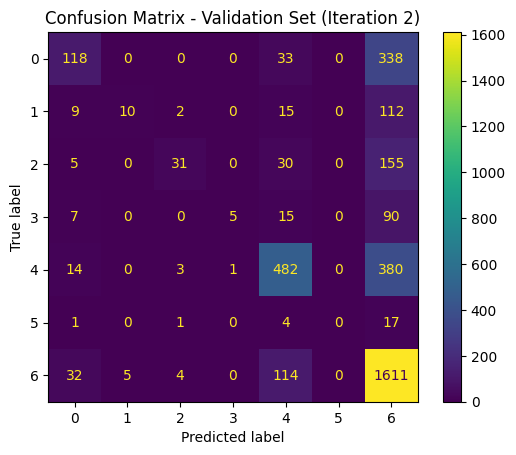

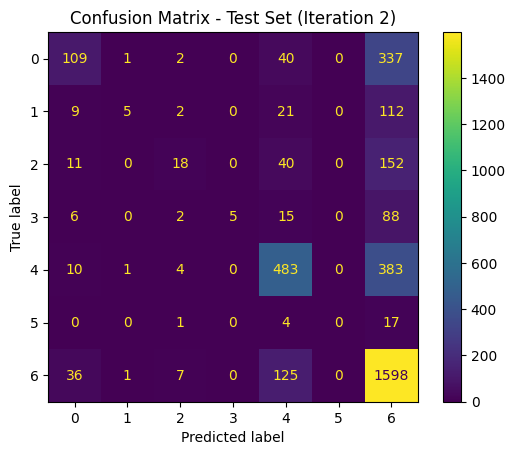

In [90]:
# Step 9: Display Confusion Matrices
print("Step 9: Print confusion matrices for validation and test sets.")

#️ Confusion Matrix for Validation Set
disp_val = ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
disp_val.ax_.set_title("Confusion Matrix - Validation Set (Iteration 2)")
plt.show()

#️ Confusion Matrix for Test Set
disp_test = ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
disp_test.ax_.set_title("Confusion Matrix - Test Set (Iteration 2)")
plt.show()

Step 10: Plot the learning curve.


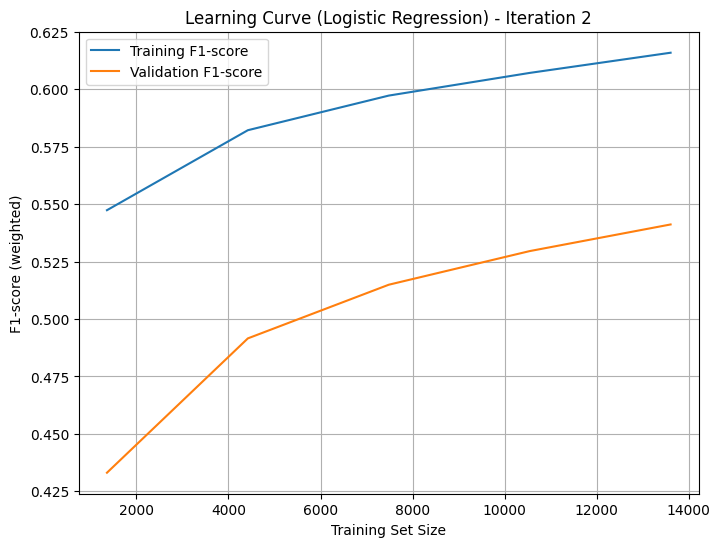

In [91]:
# Step 10: Generate learning curve data and plot the learning curve
train_sizes, train_scores, val_scores = learning_curve(
    logreg_model,          # model
    X_train_tfidf,         # features (TF-IDF transformed)
    y_train,               # labels
    cv=5,                  # 5-fold cross-validation
    scoring='f1_weighted', # metric to evaluate
    n_jobs=-1              # use all processors
)

#️ Compute mean and std for plotting
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

#️ Plot learning curve
print("Step 10: Plot the learning curve.")
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training F1-score')
plt.plot(train_sizes, val_scores_mean, label='Validation F1-score')
plt.title('Learning Curve (Logistic Regression) - Iteration 2')
plt.xlabel('Training Set Size')
plt.ylabel('F1-score (weighted)')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
#️ Step 11: Get indices of misclassified samples and display examples
misclassified_indices = np.where(y_test != y_test_pred)[0]

#️ Print a few examples of misclassified text
print("Step 11: Print misclassified examples:")
for i in misclassified_indices[:5]:  
    print(f"\nText: {X_test.iloc[i]}")
    print(f"True Label: {target_names[y_test.iloc[i]]}")
    print(f"Predicted Label: {target_names[y_test_pred[i]]}")

Step 11: Print misclassified examples:

Text: Do not grab this to me , do not do it to me !
True Label: anger
Predicted Label: surprise

Text: If this is not ready , certain people can take my place .
True Label: anger
Predicted Label: neutral

Text: No , I have a little bubble broken .
True Label: surprise
Predicted Label: neutral

Text: Yes , August 27 . We invite all residents to this event , but I hope that also tourists ,
True Label: happiness
Predicted Label: neutral

Text: say nothing seriously , but he always laughs like
True Label: happiness
Predicted Label: neutral


## Testing

### Original test dataset

New test dataset loaded successfully. Preview:


,Unnamed: 0,text,emotion,sub-emotion,processed_text,emotion_code
0,0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,excitement,Hang on to your seats because Asia's Next Top ...,0
1,1,Thousands of model hopefuls from all over Asia...,happiness,optimism,Thousands of model hopefuls from all over Asia...,0
2,2,But only the standout modeling talent were cho...,happiness,pride,But only the standout modeling talent were cho...,0
3,3,Prepare for an adventure of a lifetime,happiness,excitement,Prepare for an adventure of a lifetime,0
4,4,All I can say girls for this fierce fifth seas...,fear,excitement,All I can say girls for this fierce fifth seas...,3


Test Dataset Accuracy: 0.63
Classification Report on New Test Data:

              precision    recall  f1-score   support

   happiness       0.20      0.20      0.20        86
     sadness       1.00      0.00      0.00        26
       anger       0.12      0.04      0.06        25
        fear       1.00      0.00      0.00        19
    surprise       0.07      0.53      0.13        17
     disgust       1.00      0.00      0.00         4
     neutral       0.80      0.76      0.78       683

    accuracy                           0.63       860
   macro avg       0.60      0.22      0.17       860
weighted avg       0.72      0.63      0.64       860

Confusion Matrix for New Test Data:


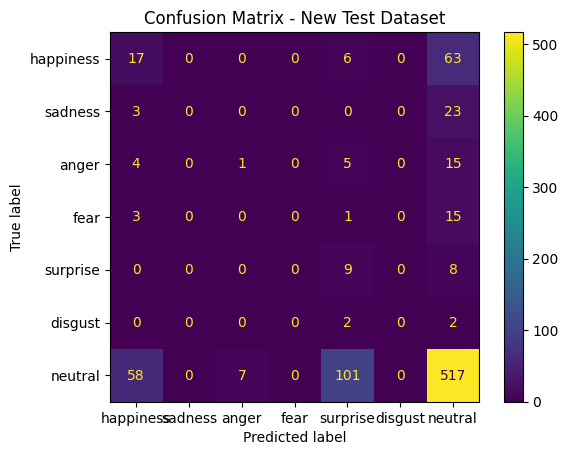


Misclassified Examples:

Text: Hang on to your seats because Asia's Next Top Model is back with a vengeance
True Label: happiness
Predicted Label: neutral

Text: Thousands of model hopefuls from all over Asia jumped at the chance to pursue their supermodel dream
True Label: happiness
Predicted Label: neutral

Text: But only the standout modeling talent were chosen as our final 14
True Label: happiness
Predicted Label: neutral

Text: Prepare for an adventure of a lifetime
True Label: happiness
Predicted Label: neutral

Text: All I can say girls for this fierce fifth season is be prepared to expect the unexpected
True Label: fear
Predicted Label: neutral


In [93]:
#️ Define the path for the new test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\data\preprocessed\test_g21.csv"

#️ Load the new test dataset
df_test = pd.read_csv(test_data_path)

#️ Display dataset preview
print("New test dataset loaded successfully. Preview:")
display(df_test.head())

#️ Check for missing values in the processed text column
missing_values = df_test['processed_text'].isna().sum()
if missing_values > 0:
    print(f"Warning: {missing_values} missing rows found in the test dataset. Removing...")
    df_test = df_test.dropna(subset=['processed_text'])
    print(f"Rows after removing missing values: {df_test.shape[0]}")

#️ Transform processed text using the trained TF-IDF vectorizer (do NOT fit again)
X_test_new_tfidf = vectorizer.transform(df_test['processed_text'].astype(str))

# Make predictions using the trained Logistic Regression model
y_test_new_pred = logreg_model.predict(X_test_new_tfidf)

#️ Evaluate model performance on the new test dataset
accuracy_new = accuracy_score(df_test['emotion_code'], y_test_new_pred)
print(f"Test Dataset Accuracy: {accuracy_new:.2f}")

#️ Create a mapping from emotion_code to emotion label (safe dictionary-based lookup)
emotion_map = df_test.drop_duplicates(subset="emotion_code").set_index("emotion_code")["emotion"].to_dict()

#️ Prepare label names sorted by emotion_code for the classification report
target_names_test = [emotion_map[i] for i in sorted(emotion_map.keys())]

#️ Generate classification report
print("Classification Report on New Test Data:\n")
print(classification_report(df_test['emotion_code'], y_test_new_pred, target_names=target_names_test, zero_division=1))

#️ Display confusion matrix
print("Confusion Matrix for New Test Data:")
ConfusionMatrixDisplay.from_predictions(df_test['emotion_code'], y_test_new_pred, display_labels=target_names_test)
plt.title("Confusion Matrix - New Test Dataset")
plt.show()

#️ Print a few misclassified examples
print("\nMisclassified Examples:")
misclassified_indices = np.where(df_test['emotion_code'] != y_test_new_pred)[0]
for i in misclassified_indices[:5]:
    print(f"\nText: {df_test['processed_text'].iloc[i]}")
    print(f"True Label: {emotion_map[df_test['emotion_code'].iloc[i]]}")
    print(f"Predicted Label: {emotion_map[y_test_new_pred[i]]}")


### ChatGPT relabeled test dataset

New test dataset loaded successfully. Preview:


,Unnamed: 0,text,emotion,processed_text,emotion_code
0,0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,Hang on to your seats because Asia's Next Top ...,0
1,1,Thousands of model hopefuls from all over Asia...,neutral,Thousands of model hopefuls from all over Asia...,6
2,2,But only the standout modeling talent were cho...,neutral,But only the standout modeling talent were cho...,6
3,3,Prepare for an adventure of a lifetime,happiness,Prepare for an adventure of a lifetime,0
4,4,All I can say girls for this fierce fifth seas...,happiness,All I can say girls for this fierce fifth seas...,0


Test Dataset Accuracy: 0.72
Classification Report on New Test Data:

              precision    recall  f1-score   support

   happiness       0.06      0.13      0.08        39
     sadness       1.00      0.00      0.00         2
       anger       0.50      0.80      0.62         5
        fear       1.00      0.00      0.00         7
    surprise       0.03      0.50      0.06         8
     neutral       0.94      0.75      0.84       799

    accuracy                           0.72       860
   macro avg       0.59      0.36      0.27       860
weighted avg       0.89      0.72      0.78       860

Confusion Matrix for New Test Data:

Misclassified Examples:

Text: Hang on to your seats because Asia's Next Top Model is back with a vengeance
True Label: happiness
Predicted Label: neutral

Text: Prepare for an adventure of a lifetime
True Label: happiness
Predicted Label: neutral

Text: All I can say girls for this fierce fifth season is be prepared to expect the unexpected
True La

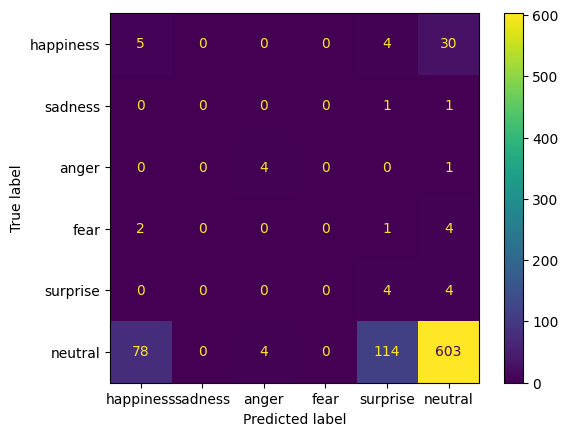

In [94]:
#️ Define the path for the new test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\data\preprocessed\test_gpt.csv"

#️ Load the new test dataset
df_test = pd.read_csv(test_data_path)

#️ Display dataset preview
print("New test dataset loaded successfully. Preview:")
display(df_test.head())

#️ Check for missing values in the processed text column
missing_values = df_test['processed_text'].isna().sum()
if missing_values > 0:
    print(f"Warning: {missing_values} missing rows found in the test dataset. Removing...")
    df_test = df_test.dropna(subset=['processed_text'])
    print(f"Rows after removing missing values: {df_test.shape[0]}")

#️ Transform processed text using the trained TF-IDF vectorizer (do NOT fit again)
X_test_new_tfidf = vectorizer.transform(df_test['processed_text'].astype(str))

# Make predictions using the trained Logistic Regression model
y_test_new_pred = logreg_model.predict(X_test_new_tfidf)

#️ Evaluate model performance on the new test dataset
accuracy_new = accuracy_score(df_test['emotion_code'], y_test_new_pred)
print(f"Test Dataset Accuracy: {accuracy_new:.2f}")

# Create a complete mapping from training data (or fallback to known classes)
all_emotion_codes = sorted(set(df_test['emotion_code']) | set(y_test_new_pred))

# Use full emotion label map from the original dataset to ensure consistency
emotion_map_full = df_cleaned.drop_duplicates(subset="emotion_code").set_index("emotion_code")["emotion"].to_dict()

# Safe label names even if some codes weren't seen in this test set
target_names_test = [emotion_map_full.get(i, f"Unknown_{i}") for i in all_emotion_codes]

# Generate classification report with full label list
print("Classification Report on New Test Data:\n")
print(classification_report(
    df_test['emotion_code'],
    y_test_new_pred,
    labels=all_emotion_codes,
    target_names=target_names_test,
    zero_division=1
))

# Display confusion matrix
print("Confusion Matrix for New Test Data:")
ConfusionMatrixDisplay.from_predictions(
    df_test['emotion_code'],
    y_test_new_pred,
    display_labels=target_names_test
)

#️ Print a few misclassified examples
print("\nMisclassified Examples:")
misclassified_indices = np.where(df_test['emotion_code'] != y_test_new_pred)[0]
for i in misclassified_indices[:5]: 
    print(f"\nText: {df_test['processed_text'].iloc[i]}")
    print(f"True Label: {emotion_map[df_test['emotion_code'].iloc[i]]}")
    print(f"Predicted Label: {emotion_map[y_test_new_pred[i]]}")

### Task 7 test dataset

New test dataset loaded successfully. Preview:


,Unnamed: 0,text,emotion,sub-emotion,processed_text,emotion_code
0,0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,excitement,Hang on to your seats because Asia's Next Top ...,0
1,1,Thousands of model hopefuls from all over Asia...,happiness,optimism,Thousands of model hopefuls from all over Asia...,0
2,2,But only the standout modeling talent were cho...,happiness,pride,But only the standout modeling talent were cho...,0
3,3,Prepare for an adventure of a lifetime,happiness,excitement,Prepare for an adventure of a lifetime,0
4,4,All I can say girls for this fierce fifth seas...,fear,excitement,All I can say girls for this fierce fifth seas...,3


Test Dataset Accuracy: 0.64
Classification Report on New Test Data:

              precision    recall  f1-score   support

   happiness       0.19      0.19      0.19        83
     sadness       1.00      0.00      0.00        25
       anger       0.12      0.04      0.06        24
        fear       1.00      0.00      0.00        18
    surprise       0.07      0.56      0.13        16
     disgust       1.00      0.00      0.00         4
     neutral       0.81      0.76      0.78       690

    accuracy                           0.64       860
   macro avg       0.60      0.22      0.17       860
weighted avg       0.73      0.64      0.65       860

Confusion Matrix for New Test Data:


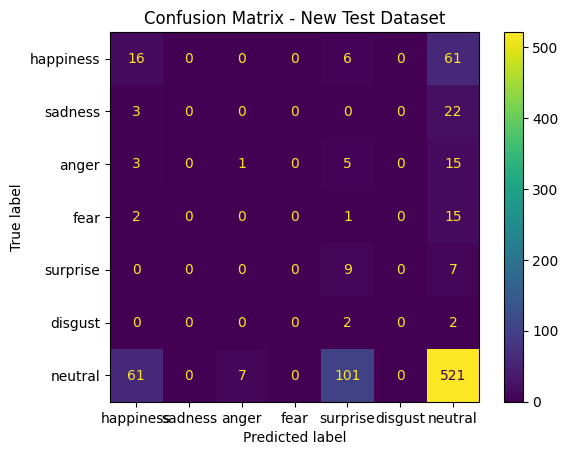


Misclassified Examples:

Text: Hang on to your seats because Asia's Next Top Model is back with a vengeance
True Label: happiness
Predicted Label: neutral

Text: Thousands of model hopefuls from all over Asia jumped at the chance to pursue their supermodel dream
True Label: happiness
Predicted Label: neutral

Text: But only the standout modeling talent were chosen as our final 14
True Label: happiness
Predicted Label: neutral

Text: Prepare for an adventure of a lifetime
True Label: happiness
Predicted Label: neutral

Text: All I can say girls for this fierce fifth season is be prepared to expect the unexpected
True Label: fear
Predicted Label: neutral


In [95]:
#️ Define the path for the new test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\data\preprocessed\test_task7.csv"

#️ Load the new test dataset
df_test = pd.read_csv(test_data_path)

#️ Display dataset preview
print("New test dataset loaded successfully. Preview:")
display(df_test.head())

#️ Check for missing values in the processed text column
missing_values = df_test['processed_text'].isna().sum()
if missing_values > 0:
    print(f"Warning: {missing_values} missing rows found in the test dataset. Removing...")
    df_test = df_test.dropna(subset=['processed_text'])
    print(f"Rows after removing missing values: {df_test.shape[0]}")

#️ Transform processed text using the trained TF-IDF vectorizer (do NOT fit again)
X_test_new_tfidf = vectorizer.transform(df_test['processed_text'].astype(str))

# Make predictions using the trained Logistic Regression model
y_test_new_pred = logreg_model.predict(X_test_new_tfidf)

#️ Evaluate model performance on the new test dataset
accuracy_new = accuracy_score(df_test['emotion_code'], y_test_new_pred)
print(f"Test Dataset Accuracy: {accuracy_new:.2f}")

#️ Create a mapping from emotion_code to emotion label (safe dictionary-based lookup)
emotion_map = df_test.drop_duplicates(subset="emotion_code").set_index("emotion_code")["emotion"].to_dict()

#️ Prepare label names sorted by emotion_code for the classification report
target_names_test = [emotion_map[i] for i in sorted(emotion_map.keys())]

#️ Generate classification report
print("Classification Report on New Test Data:\n")
print(classification_report(df_test['emotion_code'], y_test_new_pred, target_names=target_names_test, zero_division=1))

#️ Display confusion matrix
print("Confusion Matrix for New Test Data:")
ConfusionMatrixDisplay.from_predictions(df_test['emotion_code'], y_test_new_pred, display_labels=target_names_test)
plt.title("Confusion Matrix - New Test Dataset")
plt.show()

#️ Print a few misclassified examples
print("\nMisclassified Examples:")
misclassified_indices = np.where(df_test['emotion_code'] != y_test_new_pred)[0]
for i in misclassified_indices[:5]:
    print(f"\nText: {df_test['processed_text'].iloc[i]}")
    print(f"True Label: {emotion_map[df_test['emotion_code'].iloc[i]]}")
    print(f"Predicted Label: {emotion_map[y_test_new_pred[i]]}")